# Módulo 1: Introducción a la Inteligencia Artificial
## Notebook 2: Conceptos Básicos de Machine Learning con Scikit-Learn

En este notebook, exploraremos los fundamentos del Aprendizaje Automático (Machine Learning) utilizando **Scikit-Learn (sklearn)**, la biblioteca de ML más popular y utilizada en Python.

### Objetivos de Aprendizaje:
1. Comprender el flujo de trabajo estándar en Machine Learning: preparación de datos, división de entrenamiento/prueba, entrenamiento del modelo y evaluación.
2. Implementar un problema de **Regresión** (predicción de valores continuos).
3. Implementar un problema de **Clasificación** (predicción de etiquetas discretas/categorías).
4. Implementar un problema de **Clustering** (aprendizaje no supervisado para agrupar datos).
5. Familiarizarse con métricas básicas de evaluación como MSE, R², Accuracy y Matrices de Confusión.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import make_blobs, make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans

# Configuración de estilos para los gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Regresión Lineal: Predicción de Precios de Viviendas

La regresión es un tipo de aprendizaje supervisado donde el objetivo es predecir un valor numérico continuo (etiqueta) a partir de una o más características.

### El problema:
Supongamos que queremos predecir el precio de una vivienda basándonos únicamente en su tamaño en metros cuadrados ($m^2$).

Vamos a generar datos sintéticos que simulan esta relación lineal con un poco de ruido (variabilidad aleatoria del mercado).

Primeros 5 registros de datos de viviendas:
    Tamano_m2     Precio_USD
0  134.901425  201121.575755
1  115.852071  187468.426606
2  139.430656  224005.266467
3  165.690896  256502.184500
4  112.975399  187043.812462


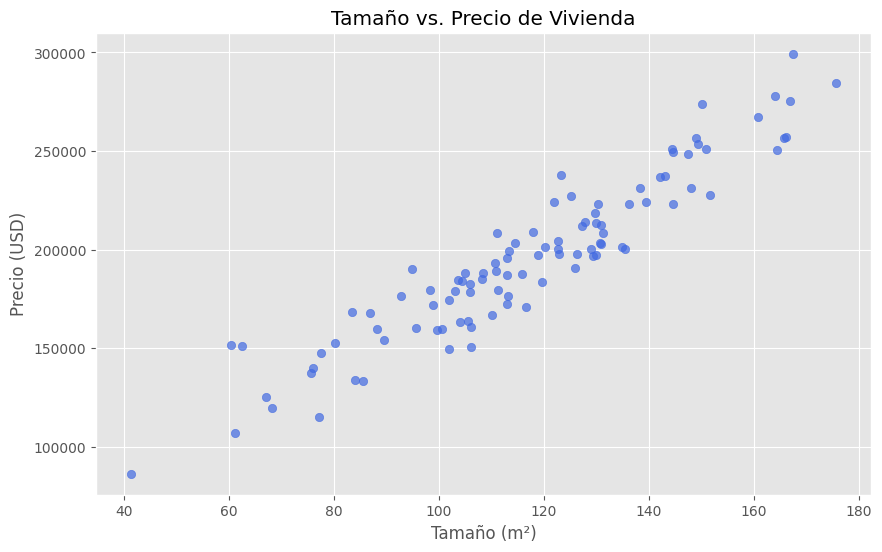

In [2]:
# 1. Generar datos sintéticos
np.random.seed(42)
tamano = np.random.normal(120, 30, 100)  # 100 viviendas de tamaño promedio 120m2
# Precio dependiente del tamaño + ruido aleatorio
precio = 1500 * tamano + np.random.normal(20000, 15000, 100) 

# Convertir a Dataframe para visualizar fácilmente
df_casas = pd.DataFrame({'Tamano_m2': tamano, 'Precio_USD': precio})
print("Primeros 5 registros de datos de viviendas:")
print(df_casas.head())

# Graficar los datos originales
plt.scatter(df_casas['Tamano_m2'], df_casas['Precio_USD'], color='royalblue', alpha=0.7)
plt.title('Tamaño vs. Precio de Vivienda')
plt.xlabel('Tamaño (m²)')
plt.ylabel('Precio (USD)')
plt.show()

### División de Entrenamiento y Prueba (Train/Test Split)

Es una regla fundamental en Machine Learning separar los datos en dos conjuntos:
*   **Entrenamiento (Train):** Datos con los que el modelo aprende los patrones (típicamente 70-80%).
*   **Prueba (Test):** Datos que el modelo no ha visto durante el entrenamiento y que usamos para simular el rendimiento del modelo en producción (típicamente 20-30%).

In [3]:
# Definir X (características) e y (etiqueta)
# Nota: sklearn espera que X sea una matriz de 2 dimensiones (n_muestras, n_características)
X = df_casas[['Tamano_m2']]
y = df_casas['Precio_USD']

# Dividir en 80% train y 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del set de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del set de prueba: {X_test.shape[0]} muestras")

# 2. Inicializar y entrenar el modelo
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train, y_train)

# Mostrar la ecuación aprendida: y = w*x + b
w = modelo_regresion.coef_[0]
b = modelo_regresion.intercept_
print(f"\nEcuación de la recta aprendida: Precio = {w:.2f} * Tamaño + {b:.2f}")

Tamaño del set de entrenamiento: 80 muestras
Tamaño del set de prueba: 20 muestras

Ecuación de la recta aprendida: Precio = 1429.25 * Tamaño + 28708.25


### Predicción y Evaluación

Ahora realizaremos predicciones sobre el conjunto de prueba (`X_test`) y compararemos las predicciones con los valores reales (`y_test`) utilizando las métricas estándar:
*   **Mean Squared Error (MSE):** El promedio de las diferencias al cuadrado entre lo predicho y lo real.
*   **R² Score (Coeficiente de Determinación):** Indica qué porcentaje de la variabilidad del precio es explicado por el modelo. Va de 0 a 1 (donde 1 es ajuste perfecto).

Mean Squared Error (MSE): 196390937.78
Root Mean Squared Error (RMSE): $14013.96
R² Score: 0.8522


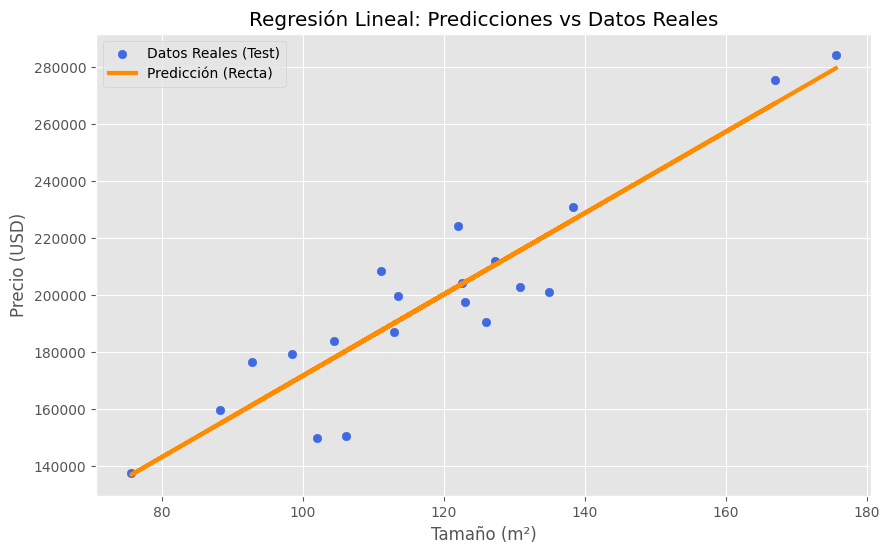

In [9]:
# Realizar predicciones
y_pred = modelo_regresion.predict(X_test)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mse):.2f}")
print(f"R² Score: {r2:.4f}")

# Graficar la recta resultante sobre los datos de prueba
plt.scatter(X_test, y_test, color='royalblue', label='Datos Reales (Test)')
plt.plot(X_test, y_pred, color='darkorange', linewidth=3, label='Predicción (Recta)')
plt.title('Regresión Lineal: Predicciones vs Datos Reales')
plt.xlabel('Tamaño (m²)')
plt.ylabel('Precio (USD)')
plt.legend()
plt.show()

### ✍️ Mini Ejercicio Práctico 1:
Usa el modelo entrenado (`modelo_regresion`) para predecir cuánto costará una casa de **150 m²**.

In [11]:
# --- TU CÓDIGO AQUÍ ---
# Pista: Crea una variable con la lista [[150]] y llama a predict
tamano_nuevo = [[150]]
precio_predicho = modelo_regresion.predict(tamano_nuevo)
print(f"El precio estimado para una casa de 150m2 es: ${precio_predicho[0]:,.2f}")

El precio estimado para una casa de 150m2 es: $243,096.44


c:\Users\franco.cipulli\Documents\Tps\AI\AI-course\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 2. Clasificación: Aprobación de Tarjetas de Crédito

La clasificación es un aprendizaje supervisado donde queremos predecir una clase discreta (ejemplo: Sí/No, Aprobado/Rechazado).

### El problema:
Una entidad financiera quiere predecir si debe aprobar una tarjeta de crédito a un cliente basándose en dos características:
1.  **Edad**
2.  **Ingresos Mensuales (en miles de USD)**

La etiqueta es **Aprobado (1)** o **Rechazado (0)**.

Primeros 5 registros de datos de clientes:
        Edad  Ingreso_Mensual_k  Aprobado
0  57.371168           8.059803         1
1  53.155548          10.323197         1
2  60.275458           6.119234         1
3  66.011485           2.902042         1
4  19.674527           5.915850         0


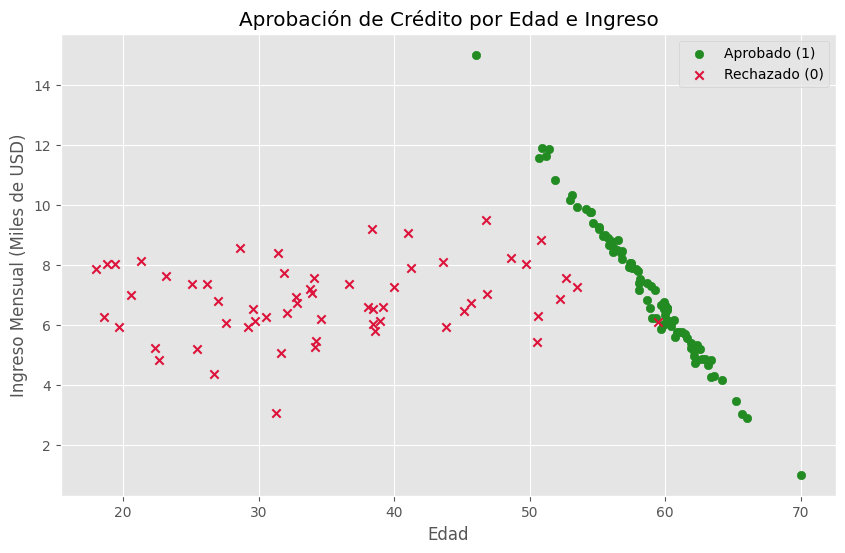

In [12]:
# Generar datos sintéticos para clasificación
np.random.seed(24)
X_clasi, y_clasi = make_classification(
    n_samples=150, 
    n_features=2, 
    n_redundant=0, 
    n_informative=2,
    n_clusters_per_class=1, 
    weights=[0.4, 0.6], # 40% rechazado, 60% aprobado
    class_sep=1.2, 
    random_state=42
)

# Escalar los datos para simular Edad e Ingresos
X_clasi[:, 0] = np.interp(X_clasi[:, 0], (X_clasi[:, 0].min(), X_clasi[:, 0].max()), (18, 70))
X_clasi[:, 1] = np.interp(X_clasi[:, 1], (X_clasi[:, 1].min(), X_clasi[:, 1].max()), (1.0, 15.0))

df_clientes = pd.DataFrame(X_clasi, columns=['Edad', 'Ingreso_Mensual_k'])
df_clientes['Aprobado'] = y_clasi

print("Primeros 5 registros de datos de clientes:")
print(df_clientes.head())

# Graficar los datos
aprobados = df_clientes[df_clientes['Aprobado'] == 1]
rechazados = df_clientes[df_clientes['Aprobado'] == 0]

plt.scatter(aprobados['Edad'], aprobados['Ingreso_Mensual_k'], color='forestgreen', marker='o', label='Aprobado (1)')
plt.scatter(rechazados['Edad'], rechazados['Ingreso_Mensual_k'], color='crimson', marker='x', label='Rechazado (0)')
plt.title('Aprobación de Crédito por Edad e Ingreso')
plt.xlabel('Edad')
plt.ylabel('Ingreso Mensual (Miles de USD)')
plt.legend()
plt.show()

### Entrenamiento de un Árbol de Decisión

Usaremos un **Árbol de Decisión (`DecisionTreeClassifier`)** para aprender las reglas de clasificación basándose en estas dos variables.

In [13]:
# Dividir los datos en entrenamiento y prueba
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clasi, y_clasi, test_size=0.25, random_state=42
)

# Inicializar y entrenar el modelo de árbol de decisión
modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_arbol.fit(X_train_c, y_train_c)

print("¡Modelo Árbol de Decisión entrenado exitosamente!")

¡Modelo Árbol de Decisión entrenado exitosamente!


### Evaluación de la Clasificación

Para medir el desempeño de nuestro clasificador utilizamos:
1.  **Exactitud (Accuracy):** Porcentaje de predicciones correctas totales.
2.  **Matriz de Confusión:** Muestra las predicciones correctas e incorrectas detalladas por clase.
3.  **Reporte de Clasificación:** Muestra precisión, recall y F1-score.

In [ ]:
# Predecir etiquetas del conjunto de prueba
y_pred_c = modelo_arbol.predict(X_test_c)

# Calcular exactitud
acc = accuracy_score(y_test_c, y_pred_c)
print(f"Exactitud (Accuracy) del modelo: {acc*100:.2f}%\n")

# Mostrar reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test_c, y_pred_c, target_names=['Rechazado', 'Aprobado']))

# Calcular la matriz de confusión
cm = confusion_matrix(y_test_c, y_pred_c)
print("Matriz de Confusión:")
print(cm)

Exactitud (Accuracy) del modelo: 92.11%

Reporte de Clasificación:
              precision    recall  f1-score   support

   Rechazado       0.88      0.93      0.90        15
    Aprobado       0.95      0.91      0.93        23

    accuracy                           0.92        38
   macro avg       0.91      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38

Matriz de Confusión:
[[14  1]
 [ 2 21]]


### ✍️ Mini Ejercicio Práctico 2:
Usa el modelo entrenado (`modelo_arbol`) para predecir si se le aprueba el crédito a un cliente de **45 años** que gana **8.5 mil USD** al mes.
Completa la celda de abajo:

In [15]:
# --- TU CÓDIGO AQUÍ ---
# Pista: El vector de entrada debe ser [[Edad, Ingreso_Mensual_k]]
cliente_nuevo = [[45, 8.5]]
prediccion_cliente = modelo_arbol.predict(cliente_nuevo)
resultado = "Aprobado" if prediccion_cliente[0] == 1 else "Rechazado"
print(f"El resultado para el cliente con 45 años e ingresos de 8.5k USD es: {resultado}")

El resultado para el cliente con 45 años e ingresos de 8.5k USD es: Rechazado


## 3. Clustering: Segmentación de Clientes (Aprendizaje No Supervisado)

En el aprendizaje no supervisado, no tenemos etiquetas (`y`). El objetivo es encontrar patrones o grupos ocultos en los datos directamente.

### El problema:
Queremos agrupar a nuestros clientes en diferentes segmentos basados en su **Ingreso Mensual (en miles de USD)** y su **Puntaje de Gasto (1-100)** en la tienda.

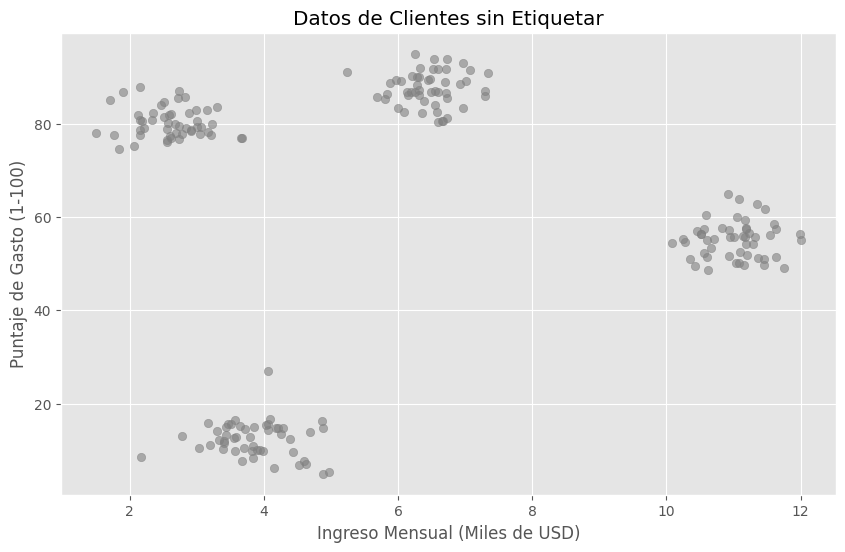

In [ ]:
# Generar datos sintéticos usando make_blobs
X_cluster, _ = make_blobs(n_samples=200, centers=4, cluster_std=0.8, random_state=42) # type: ignore

# Ajustar escala para simular ingresos y puntaje de gasto
X_cluster[:, 0] = np.interp(X_cluster[:, 0], (X_cluster[:, 0].min(), X_cluster[:, 0].max()), (1.5, 12.0))
X_cluster[:, 1] = np.interp(X_cluster[:, 1], (X_cluster[:, 1].min(), X_cluster[:, 1].max()), (5, 95))

# Graficar datos crudos (sin etiquetas)
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], color='gray', alpha=0.6)
plt.title('Datos de Clientes sin Etiquetar')
plt.xlabel('Ingreso Mensual (Miles de USD)')
plt.ylabel('Puntaje de Gasto (1-100)')
plt.show()

### Aplicando el algoritmo K-Means

**K-Means** agrupa los datos tratando de separar las muestras en $K$ grupos de igual varianza, minimizando una métrica llamada inercia.

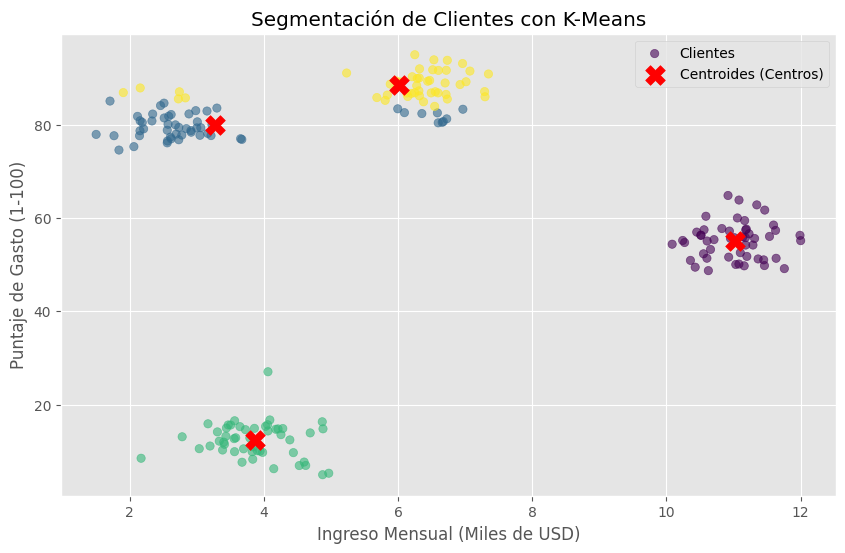

In [17]:
# Inicializar y ajustar K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_cluster)

# Obtener los centroides de cada cluster
centroides = kmeans.cluster_centers_

# Graficar los clusters con colores diferentes y los centroides
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, label='Clientes')
plt.scatter(centroides[:, 0], centroides[:, 1], color='red', marker='X', s=200, label='Centroides (Centros)')
plt.title('Segmentación de Clientes con K-Means')
plt.xlabel('Ingreso Mensual (Miles de USD)')
plt.ylabel('Puntaje de Gasto (1-100)')
plt.legend()
plt.show()

## Conclusiones

En esta introducción práctica con **Scikit-Learn** hemos cubierto:
1.  **Regresión Lineal** para predecir variables numéricas continuas.
2.  **Árboles de Decisión** para clasificar observaciones en categorías discretas.
3.  **K-Means** para descubrir grupos naturales en datos sin etiquetar.

En el siguiente módulo (**03_embeddings**), veremos cómo convertir textos en representaciones vectoriales para poder aplicar búsquedas semánticas y preparar datos para modelos de lenguaje.